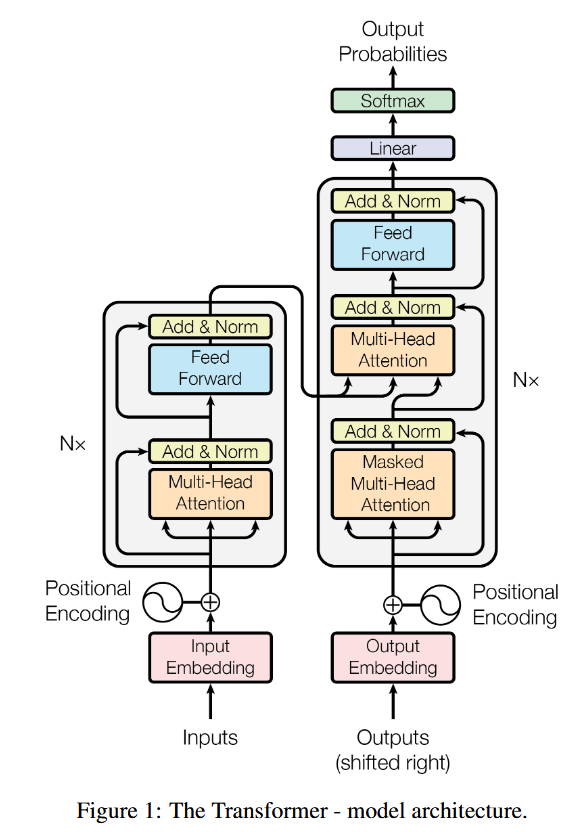

In [ ]:
import torch
import torch.nn.functional as F
torch.set_printoptions(sci_mode=False)

In [ ]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.fan_in = fan_in
        self.weights = torch.randn(fan_in, fan_out)/fan_in**0.5
        self.biases = torch.zeros(fan_out) if bias else None

    def __call__(self, inp):
        prod = inp@self.weights
        if self.biases is not None:
            prod += self.biases
        self.out = prod
        return self.out

    def parameters(self):
        biases = [self.biases] if self.biases is not None else []
        return [self.weights] + biases

class Embedding:
    def __init__(self, vocab_size, emb_size):
        self.vocab_size = vocab_size
        self.emb_size = emb_size

        self.weight = torch.randn((vocab_size, emb_size))

    def __call__(self, inp):
        self.out = self.weight[inp]
        return self.out

    def parameters(self):
        return [self.weight]

    def reset_params(self):
        self.weight = torch.randn((self.vocab_size, self.emb_size))

In [ ]:
class SelfAttention:
    def __init__(self, d_emb, heads, d_k = None, masked = False):
        self.heads = heads
        self.masked = masked
        self.d_v = d_k if d_k is not None else d_emb//heads
        self.Wq = [torch.randn(d_emb, self.d_v)/(d_emb**0.5) for _ in range(heads)]
        self.Wk = [torch.randn(d_emb, self.d_v)/(d_emb**0.5) for _ in range(heads)]
        self.Wv = [torch.randn(d_emb, self.d_v)/(d_emb**0.5) for _ in range(heads)]
        self.Wo = torch.randn(heads*self.d_v, d_emb)/((heads*self.d_v)**0.5)

    def __call__(self, X):
        out_lis = []
        for i in range(self.heads):
            Q, K = X@self.Wq[i], X@self.Wk[i]
            V = X@self.Wv[i]
            att_out = (Q @ (K.transpose(1, 2))) / ((self.d_v)**0.5)
            if self.masked:
                n = X.shape[1]
                inf = torch.ones(n, n)*float('-inf')
                inf = torch.stack([torch.tril(inf, diagonal = -1).T] * X.shape[0])
                att_out = torch.tril(att_out) + inf
            out_lis.append(torch.softmax(att_out, dim = 2) @ V)
        self.out = torch.cat(out_lis, dim = 2)
        if self.heads > 1:
            self.out = self.out@self.Wo

        return self.out
    def parameters(self):
        return self.Wq + self.Wk + self.Wv + [self.Wo]

class CrossAttention:
    def __init__(self, d_emb, heads, d_k = None):
        self.heads = heads
        self.d_v = d_k if d_k is not None else d_emb//heads
        self.Wq = [torch.randn(d_emb, self.d_v)/(d_emb**0.5) for _ in range(heads)]
        self.Wk = [torch.randn(d_emb, self.d_v)/(d_emb**0.5) for _ in range(heads)]
        self.Wv = [torch.randn(d_emb, self.d_v)/(d_emb**0.5) for _ in range(heads)]
        self.Wo = torch.randn(heads*self.d_v, d_emb)/((heads*self.d_v)**0.5)

    def __call__(self, Query, Key):
        out_lis = []
        for i in range(self.heads):
            Q, K = Query@self.Wq[i], Key@self.Wk[i]
            V = Key@self.Wv[i]
            att_out = (Q @ (K.transpose(1, 2))) / ((self.d_v)**0.5)
            out_lis.append(torch.softmax(att_out, dim = 2) @ V)
        self.out = torch.cat(out_lis, dim = 2)
        if self.heads > 1:
            self.out = self.out@self.Wo
        return self.out

    def parameters(self):
        return self.Wq + self.Wk + self.Wv + [self.Wo]

class PositionalEncode:
    def __init__(self, n_embd, max_len = 1024):
        # positional embeddings
        pe = torch.zeros(max_len, n_embd)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        C = -torch.log(torch.tensor(10000.0))
        div_term = torch.exp(torch.arange(0, n_embd, 2).float() * (C / n_embd))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe
    def __call__(self, X):
        self.out = X + torch.stack([self.pe[:X.size(1), :]] * X.size(0))
        return self.out

    def parameters(self):
        return []

class FFN:
    def __init__(self, d_emb, d_ff):
        self.W1 = torch.randn(d_emb, d_ff)*0.01
        self.b1 = torch.randn(1, d_ff)*0.001
        self.W2 = torch.randn(d_ff, d_emb)*0.01
        self.b2 = torch.randn(1, d_emb)*0.001

    def __call__(self, X):
        hidden_layer = X @ self.W1 + self.b1
        self.out = torch.max(torch.tensor(0), hidden_layer) @ self.W2 + self.b2
        return self.out

    def parameters(self):
        return [self.W1, self.b1, self.W2, self.b2]

class EncoderLayer:
    def __init__(self, d_emb, d_ff, vocab_size, multi_head):
        self.self_attention = SelfAttention(d_emb, multi_head)
        self.feed_forward = FFN(d_emb, d_ff)
        self.layer_norm_gamma1 = torch.ones(1, d_emb)
        self.layer_norm_beta1 = torch.zeros(1, d_emb)
        self.layer_norm_gamma2 = torch.ones(1, d_emb)
        self.layer_norm_beta2 = torch.zeros(1, d_emb)
        self.eps = 1e-5

        self.sub_layers = [self.self_attention, self.feed_forward]
        self.params = [self.layer_norm_gamma1, self.layer_norm_beta1, self.layer_norm_gamma2, self.layer_norm_beta2]

    def __call__(self, X_pos_encoded):
        X_s_attended = self.self_attention(X_pos_encoded)
        X_add1 = X_pos_encoded + X_s_attended
        X_norm1 = self.layer_norm_gamma1 * ((X_add1 - X_add1.mean(dim = -1).unsqueeze(-1)) / (X_add1.std(dim = -1).unsqueeze(-1)**2 + self.eps)**0.5) + self.layer_norm_beta1

        X_ffn = self.feed_forward(X_norm1)
        X_add2 = X_norm1 + X_ffn
        X_norm2 = self.layer_norm_gamma2 * ((X_add2 - X_add2.mean(dim = -1).unsqueeze(-1)) / (X_add2.std(dim = -1).unsqueeze(-1)**2 + self.eps)**0.5) + self.layer_norm_beta2
        self.out = X_norm2

        return self.out

    def parameters(self):
        params = list(self.params)
        for layer in self.sub_layers:
            params += layer.parameters()
        return params

class DecoderLayer:
    def __init__(self, d_emb, d_ff, vocab_size, multi_head, cross_attention = True):
        self.self_attention = SelfAttention(d_emb, multi_head, masked = True)
        self.cross_attention = CrossAttention(d_emb, multi_head)
        self.ca = cross_attention
        self.feed_forward = FFN(d_emb, d_ff)
        self.layer_norm_gamma1 = torch.ones(1, d_emb)
        self.layer_norm_beta1 = torch.zeros(1, d_emb)
        self.layer_norm_gamma2 = torch.ones(1, d_emb)
        self.layer_norm_beta2 = torch.zeros(1, d_emb)
        self.layer_norm_gamma3 = torch.ones(1, d_emb)
        self.layer_norm_beta3 = torch.zeros(1, d_emb)
        self.eps = 1e-5

        self.sub_layers = [self.self_attention, self.feed_forward]
        self.params = [self.layer_norm_gamma1, self.layer_norm_beta1, self.layer_norm_gamma3, self.layer_norm_beta3]

        if cross_attention:
            self.params += [self.layer_norm_gamma2, self.layer_norm_beta2]
            self.sub_layers.append(self.cross_attention)

    def __call__(self, X_pos_encoded, Xk = None):
        X_s_attended = self.self_attention(X_pos_encoded)
        X_add1 = X_pos_encoded + X_s_attended
        X_norm1 = self.layer_norm_gamma1 * ((X_add1 - X_add1.mean(dim = -1).unsqueeze(-1)) / (X_add1.std(dim = -1).unsqueeze(-1)**2 + self.eps)**0.5) + self.layer_norm_beta1
        X_next = X_norm1

        if self.ca:
            X_c_attended = self.cross_attention(X_next, Xk)
            X_add2 = X_next + X_c_attended
            X_norm2 = self.layer_norm_gamma2 * ((X_add2 - X_add2.mean(dim = -1).unsqueeze(-1)) / (X_add2.std(dim = -1).unsqueeze(-1)**2 + self.eps)**0.5) + self.layer_norm_beta2
            X_next = X_norm2

        X_ffn = self.feed_forward(X_next)
        X_add3 = X_next + X_ffn
        X_norm3 = self.layer_norm_gamma3 * ((X_add3 - X_add3.mean(dim = -1).unsqueeze(-1)) / (X_add3.std(dim = -1).unsqueeze(-1)**2 + self.eps)**0.5) + self.layer_norm_beta3
        self.out = X_norm3

        return self.out

    def parameters(self):
        params = list(self.params)
        for layer in self.sub_layers:
            params += layer.parameters()
        return params

class Transformer:
    def __init__(self, encoders, decoders):
        self.encoders = encoders
        self.decoders = decoders
        self.params = [p for layer in (self.encoders + self.decoders) for p in layer.parameters()]

    def __call__(self, input_encoding, output_encoding):
        x = input_encoding
        for encoder in self.encoders:
            x = encoder(x)
        # x will be the encoding by now
        y = output_encoding
        for decoder in self.decoders:
            y = decoder(x, y)
        return y

    def parameters(self):
        return self.params

In [ ]:
with open("shakespeare.txt", "r") as f:
    text = f.read()
alphabet = sorted(list(set(text)))
stoi = {letter : i for i, letter in enumerate(alphabet)}
itos = {i : letter for i, letter in enumerate(alphabet)}
vocab_size = len(alphabet)
encode = lambda txt : [stoi[t] for t in txt]
decode = lambda enc : "".join([itos[i] for i in enc])

encoded_text = torch.tensor(encode(text)).long()

n = int(0.9*len(encoded_text))
train_data = encoded_text[:n]
val_data = encoded_text[n:]

In [ ]:
print(alphabet)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
len(alphabet)

65

In [ ]:
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input='shakespeare.txt',
    model_prefix='shakespeare_bpe',
    vocab_size=1000,
    model_type='bpe',        # or 'unigram' (SentencePiece's default, also good)
    character_coverage=1.0,  # 1.0 for languages with small char sets like English
)

sp = spm.SentencePieceProcessor(model_file='shakespeare_bpe.model')

encoded_text = torch.tensor(sp.encode(text)).long()

n = int(0.9*len(encoded_text))
train_data = encoded_text[:n]
val_data = encoded_text[n:]

In [ ]:
vocab_size = sp.vocab_size()

In [ ]:
def batch(split):
    split_dict = {
        "train": train_data,
        "val": val_data,
    }
    data = split_dict[split]
    ix = torch.randint(0, len(data) - window, (batch_size,))
    x = torch.stack([data[i:i+window] for i in ix])
    y = torch.stack([data[i+1:i+1+window] for i in ix])
    return x, y

def training_examples(x, y):
    """
    For each encoder prefix length L (1..window):
      x_examples[L-1] = first L chars of the source window       (encoder input)
      y_examples[L-1] = SOS + continuation[:-1]                  (decoder input, teacher-forced)
      targets[L-1]    = continuation                             (loss target — one step ahead)
    """
    sos = torch.zeros(x.size(0), 1).long()

    x_examples = [x[:, :L] for L in range(1, window + 1)]

    y_examples, targets = [], []
    for L in range(1, window + 1):
        continuation = y[:, L - 1:]                                   # correct next chars after the prefix
        decoder_in = torch.cat((sos, continuation[:, :-1]), dim=1)    # shift right, drop last char
        y_examples.append(decoder_in)
        targets.append(continuation)

    return x_examples, y_examples, targets

In [ ]:
d_emb = 512
d_ff = 3*d_emb
heads = 8
window = 256
batch_size = 48
warmup_steps = 400

len(encoded_text)

2733406

In [ ]:
Embed = Embedding(vocab_size, d_emb)
Pos_enc = PositionalEncode(d_emb)

Decode1 = DecoderLayer(d_emb, d_ff, vocab_size, heads, cross_attention=False)
Decode2 = DecoderLayer(d_emb, d_ff, vocab_size, heads, cross_attention=False)
Decode3 = DecoderLayer(d_emb, d_ff, vocab_size, heads, cross_attention=False)
Decode4 = DecoderLayer(d_emb, d_ff, vocab_size, heads, cross_attention=False)

lin = Linear(d_emb, vocab_size)
lin.weights.data *= 0.01

parameter = Embed.parameters() + Decode1.parameters() + Decode2.parameters() + Decode3.parameters() + Decode4.parameters() + lin.parameters()

for p in parameter:
    p.requires_grad = True

total_params = sum(t.nelement() for t in parameter)
print("Total params: ", total_params)

Total params:  10601569


In [ ]:
accum_mt = [torch.zeros_like(p) for p in parameter]
accum_vt = [torch.zeros_like(p) for p in parameter]

beta1, beta2 = 0.9, 0.999
eps = 1e-6

t_loss, v_loss = [], []

for step in range(3000):
    X, Y = batch("train")
    PE_X = Pos_enc(Embed(X))
    D1 = Decode1(PE_X)
    D2 = Decode2(D1)
    D3 = Decode3(D2)
    D4 = Decode4(D3)

    D_fin = lin(D4)
    loss = F.cross_entropy(D_fin.transpose(1, 2), Y)

    for p in parameter:
        p.grad = None
    loss.backward()

    update_steps = step + 1
    lr = (d_emb ** -0.5) * min(update_steps ** -0.5, update_steps * warmup_steps ** -1.5)
    torch.nn.utils.clip_grad_norm_(parameter, max_norm=1.0)
    for i in range(len(parameter)):
        if parameter[i].grad is None:
            continue
        accum_mt[i] = beta1 * accum_mt[i] + (1 - beta1) * parameter[i].grad
        accum_vt[i] = beta2 * accum_vt[i] + (1 - beta2) * parameter[i].grad ** 2
        mt_hat = accum_mt[i] / (1 - beta1 ** update_steps)
        vt_hat = accum_vt[i] / (1 - beta2 ** update_steps)
        parameter[i].data += -(mt_hat / (vt_hat ** 0.5 + eps)) * lr

    if step % 10 == 0:
        with torch.no_grad():
            X_v, Y_v = batch("val")
            PE_X_v = Pos_enc(Embed(X_v))
            D1_v = Decode1(PE_X_v)
            D2_v = Decode2(D1_v)
            D3_v = Decode3(D2_v)
            D4_v = Decode4(D3_v)
            D_fin_v = lin(D4_v)
            loss_v = F.cross_entropy(D_fin_v.transpose(1, 2), Y_v)

        t_loss.append(loss.item())
        v_loss.append(loss_v.item())

        if step % 100 == 0:
            print(f"iteration: {step:5d} | loss: {loss.item():.4f} | val loss: {loss_v.item():.4f}")
            print(f"----learn: {lr:.10f}")

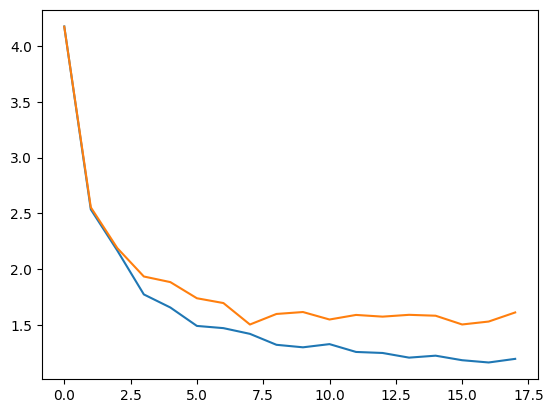

In [ ]:
import matplotlib.pyplot as plt
plt.plot(t_loss)
plt.plot(v_loss)

In [ ]:
txt_X = """ROMEO:
But soft, what light through yonder window breaks?
"""
X = torch.tensor(encode(txt_X))[-window:].view( 1, -1) if len(txt_X) >= window else torch.tensor(encode(txt_X)).view( 1, -1)

In [ ]:
for step in range(10000):
    # print(X)
    PE_X = Pos_enc(Embed(X))
    D1 = Decode1(PE_X)
    D2 = Decode2(D1)
    D3 = Decode3(D2)
    D4 = Decode4(D3)
    D_fin = lin(D4)
    relevent = D_fin[:, -1, :][0]

    t = torch.softmax(relevent, dim = 0)

    idx = torch.multinomial(torch.softmax(relevent, dim = 0), num_samples = 1).item()
    ch = itos[idx]

    txt_X += ch
    print(txt_X)
    print("________________________")
    X = torch.tensor([X.tolist()[0][1:] + [idx]])